# User Acquisition Analysis
**Soal 4: Descriptive Analysis & Suggestions**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [2]:
# Load semua tabel
ads_spent   = pd.read_csv('../data/csv/ads_spent.csv', parse_dates=['date_id'])
campaign    = pd.read_csv('../data/csv/campaign.csv')
camp_flag   = pd.read_csv('../data/csv/campaign_flag.csv')
donation    = pd.read_csv('../data/csv/donation.csv')
don_status  = pd.read_csv('../data/csv/donation_statuses.csv')
ticket      = pd.read_csv('../data/csv/ticket.csv')
user        = pd.read_csv('../data/csv/user.csv')
visit       = pd.read_csv('../data/csv/visit.csv', parse_dates=['date_id'])

# Convert unix timestamp ke datetime
for df, col in [(campaign, 'created'), (donation, 'created'), (user, 'created')]:
    df[col + '_dt'] = pd.to_datetime(df[col], unit='s')

print('Data loaded successfully.')

Data loaded successfully.


## 2. Tren User Baru per Bulan

In [3]:
ORANGE_PALETTE = ['#E8500A', '#F47B20', '#F9A55A', '#FBCB9A', '#FDE3C8']

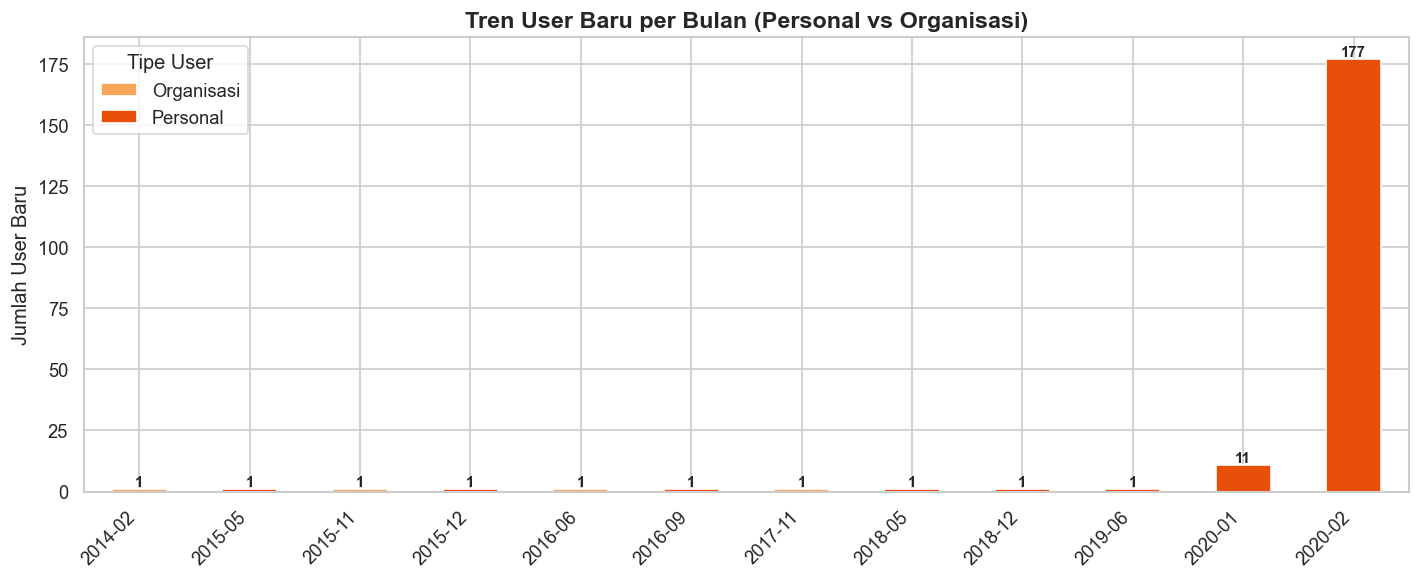

In [4]:
user['year_month'] = user['created_dt'].dt.to_period('M').astype(str)

monthly_new_user = user.groupby(['year_month', 'type']).size().reset_index(name='total_user')

monthly_pivot = monthly_new_user.pivot(index='year_month', columns='type', values='total_user').fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))

monthly_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color={'PERSONAL': '#E8500A', 'ORGANIZATION': '#F9A55A'},
    edgecolor='white'
)

for i, (idx, row) in enumerate(monthly_pivot.iterrows()):
    total = int(row.sum())
    ax.text(i, total, f'{total}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Tren User Baru per Bulan (Personal vs Organisasi)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Jumlah User Baru')
ax.legend(title='Tipe User', labels=['Organisasi', 'Personal'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_new_user_trend.png')
plt.show()

## 3. Distribusi User per Provinsi

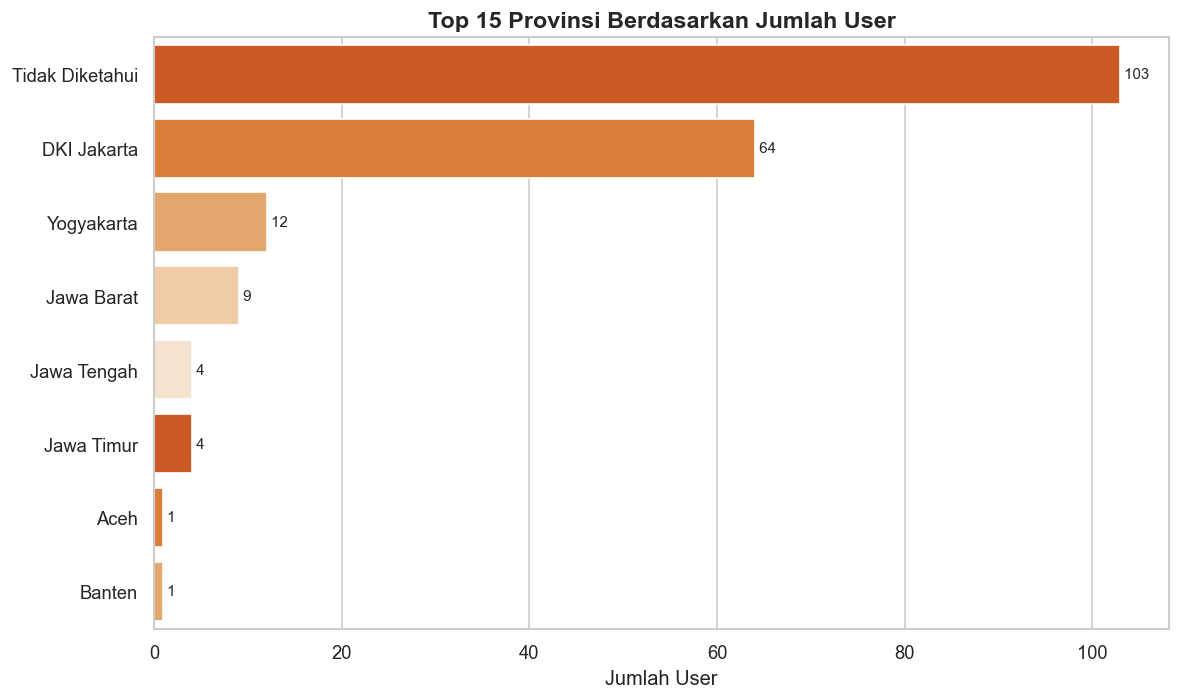

In [5]:
province_mapping = {
    'Probolinggo': 'Jawa Timur',
    'Cianjur':     'Jawa Barat',
    'Bandung':     'Jawa Barat',
    'Wonogiri':    'Jawa Tengah',
    'Boyolali':    'Jawa Tengah',
    'Other':       'Tidak Diketahui'
}

user['province_clean'] = user['province'].replace(province_mapping)

province_dist = (
    user.groupby('province_clean').size()
    .reset_index(name='total_user')
    .sort_values('total_user', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=province_dist, y='province_clean', x='total_user', ax=ax, palette=ORANGE_PALETTE)

for i, v in enumerate(province_dist['total_user']):
    ax.text(v, i, f' {int(v)}', va='center', fontsize=9)

ax.set_title('Top 15 Provinsi Berdasarkan Jumlah User', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah User')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('user_by_province.png')
plt.show()

## 4. Konversi User Baru ke Donasi Pertama

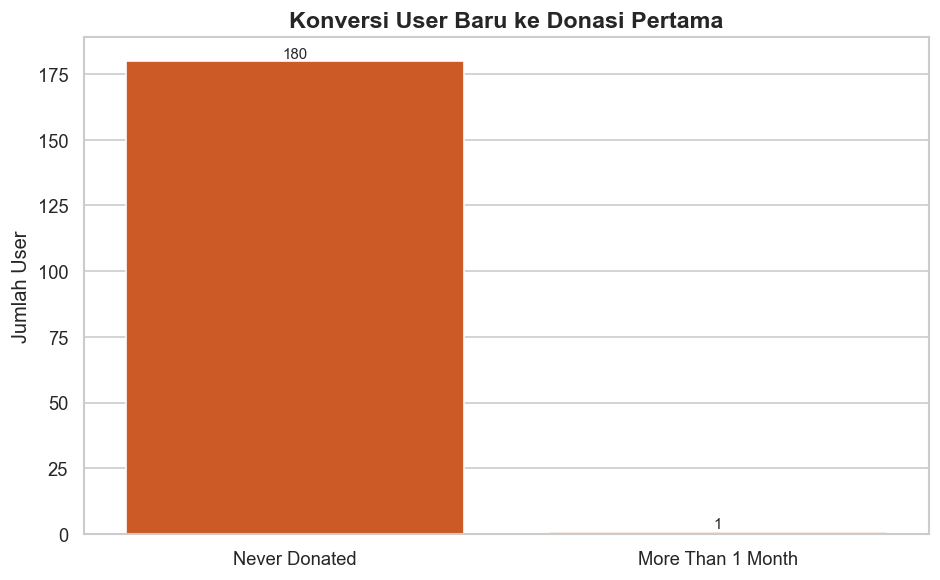

Never Donated        180
More Than 1 Month      1
Name: bucket, dtype: int64


In [6]:
verified_donation = donation[donation['status'] == 4].copy()
verified_donation['created_dt'] = pd.to_datetime(verified_donation['created'], unit='s')

first_donation = (
    verified_donation.groupby('user_id')['created_dt']
    .min().reset_index()
    .rename(columns={'created_dt': 'first_donation_date'})
)

user_conversion = user[['id', 'created_dt']].merge(
    first_donation, left_on='id', right_on='user_id', how='left'
)
user_conversion['days_to_first_donation'] = (
    user_conversion['first_donation_date'] - user_conversion['created_dt']
).dt.days

user_conversion = user_conversion[
    (user_conversion['days_to_first_donation'] >= 0) |
    (user_conversion['days_to_first_donation'].isna())
]

def bucket(d):
    if pd.isna(d):  return 'Never Donated'
    if d == 0:      return 'Same Day'
    if d <= 7:      return 'Within 1 Week'
    if d <= 30:     return 'Within 1 Month'
    return 'More Than 1 Month'

user_conversion['bucket'] = user_conversion['days_to_first_donation'].apply(bucket)

bucket_counts = user_conversion['bucket'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=bucket_counts.index, y=bucket_counts.values, ax=ax, palette=ORANGE_PALETTE)

for i, v in enumerate(bucket_counts):
    ax.text(i, v, f'{int(v)}', ha='center', va='bottom', fontsize=9)

ax.set_title('Konversi User Baru ke Donasi Pertama', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Jumlah User')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('user_conversion_bucket.png')
plt.show()

print(bucket_counts)

## 5. Platform Donasi Pertama

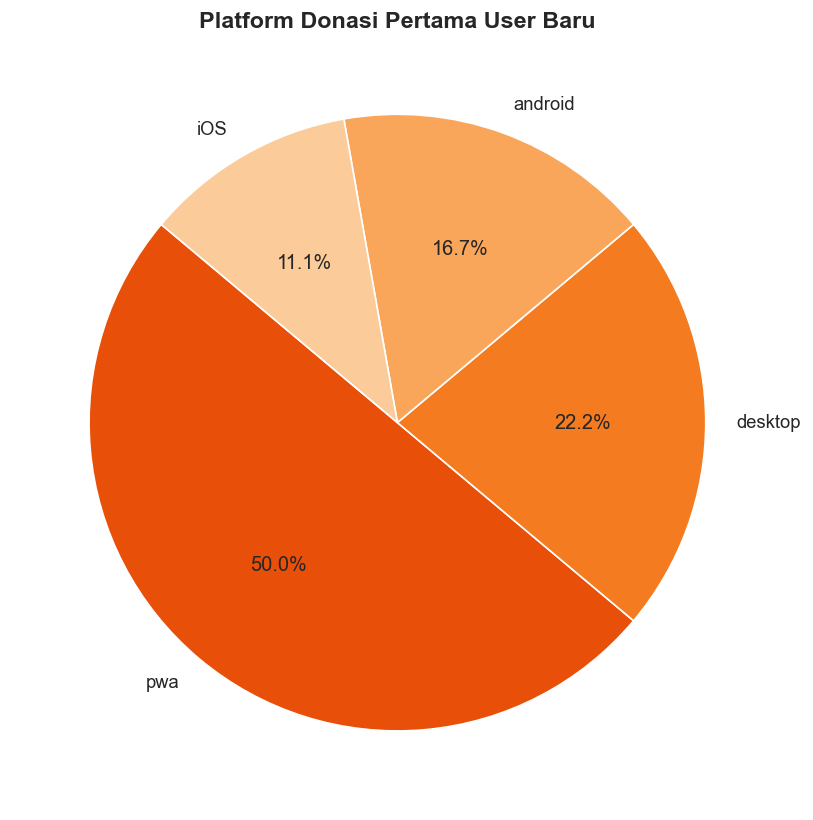

In [7]:
verified_donation_sorted = verified_donation.sort_values('created')
first_platform = verified_donation_sorted.groupby('user_id').first().reset_index()[['user_id','platform']]

platform_dist = first_platform['platform'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(platform_dist, labels=platform_dist.index, autopct='%1.1f%%',
       colors=ORANGE_PALETTE[:len(platform_dist)], startangle=140)
ax.set_title('Platform Donasi Pertama User Baru', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('first_donation_platform.png')
plt.show()

## 6. Campaign Efektif untuk User Baru

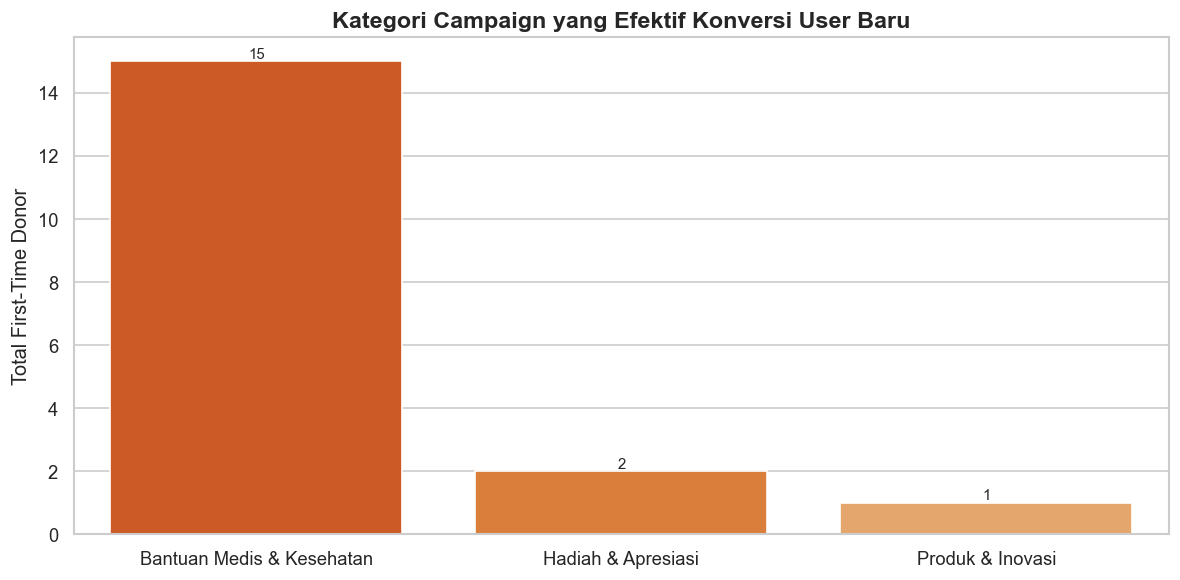

                    category  total_first_time_donor  pct_share  \
0  Bantuan Medis & Kesehatan                      15      83.33   
1         Hadiah & Apresiasi                       2      11.11   
2           Produk & Inovasi                       1       5.56   

   total_donation_amount  
0                 680000  
1                 110000  
2                  25000  


In [8]:
verified_donation_sorted = verified_donation.sort_values('created')
verified_donation_sorted['rn'] = verified_donation_sorted.groupby('user_id').cumcount() + 1

first_donation_camp = verified_donation_sorted[verified_donation_sorted['rn'] == 1][['user_id', 'campaign_id']]

first_donation_camp = first_donation_camp.merge(
    campaign[['id', 'category']], left_on='campaign_id', right_on='id', how='left'
)

first_donation_amount = verified_donation_sorted[verified_donation_sorted['rn'] == 1][['user_id', 'campaign_id', 'amount']]

first_donation_camp = first_donation_camp.merge(
    first_donation_amount[['user_id', 'campaign_id', 'amount']],
    on=['user_id', 'campaign_id'], how='left'
)

category_summary = first_donation_camp.groupby('category').agg(
    total_first_time_donor=('user_id', 'count'),
    total_donation_amount=('amount', 'sum')
).reset_index()

category_summary['pct_share'] = (
    category_summary['total_first_time_donor'] * 100.0
    / category_summary['total_first_time_donor'].sum()
).round(2)

category_summary = category_summary.sort_values('total_first_time_donor', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=category_summary, x='category', y='total_first_time_donor', ax=ax, palette=ORANGE_PALETTE)

for i, val in enumerate(category_summary['total_first_time_donor']):
    ax.text(i, val, f'{int(val)}', ha='center', va='bottom', fontsize=9)

ax.set_title('Kategori Campaign yang Efektif Konversi User Baru', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Total First-Time Donor')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('category_first_time_donor.png')
plt.show()

print(category_summary[['category', 'total_first_time_donor', 'pct_share', 'total_donation_amount']])

## 7. Retensi Donatur

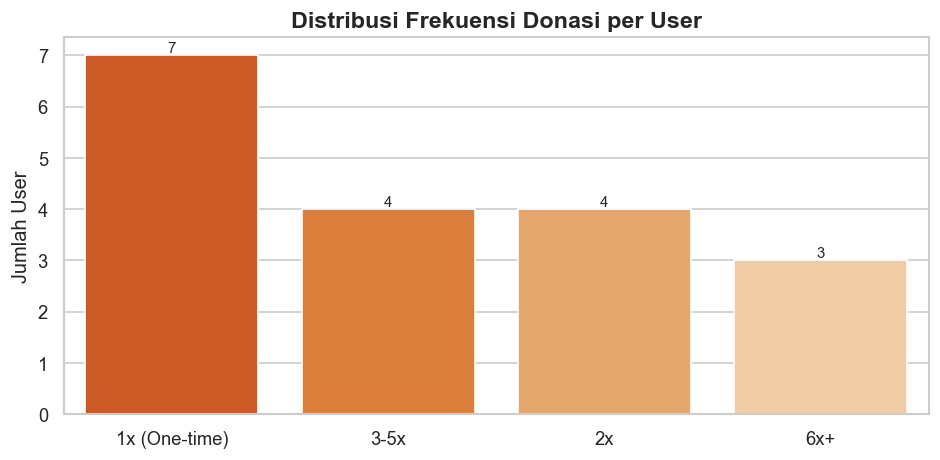

1x (One-time)    7
3-5x             4
2x               4
6x+              3
Name: freq_bucket, dtype: int64


In [9]:
user_freq = (
    verified_donation.groupby('user_id')
    .agg(total_donations=('id','count'), total_amount=('amount','sum'))
    .reset_index()
)

def freq_bucket(n):
    if n == 1: return '1x (One-time)'
    if n == 2: return '2x'
    if n <= 5: return '3-5x'
    return '6x+'

user_freq['freq_bucket'] = user_freq['total_donations'].apply(freq_bucket)
freq_summary = user_freq['freq_bucket'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=freq_summary.index, y=freq_summary.values, ax=ax, palette=ORANGE_PALETTE)

for i, v in enumerate(freq_summary):
    ax.text(i, v, f'{int(v)}', ha='center', va='bottom', fontsize=9)

ax.set_title('Distribusi Frekuensi Donasi per User', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Jumlah User')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('donation_frequency_distribution.png')
plt.show()

print(freq_summary)